In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Генерация синтетических датасетов

- make_classification (3 кластера)

In [2]:
X1, y1_true = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=3,
    random_state=42
)

- make_blobs (4 кластера)

In [3]:
X2, y2_true = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

### Нормализуем данные

In [4]:
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
X2_scaled = scaler.fit_transform(X2)

### Визуализируем синтетические данные

- Датасет 1: make_classification

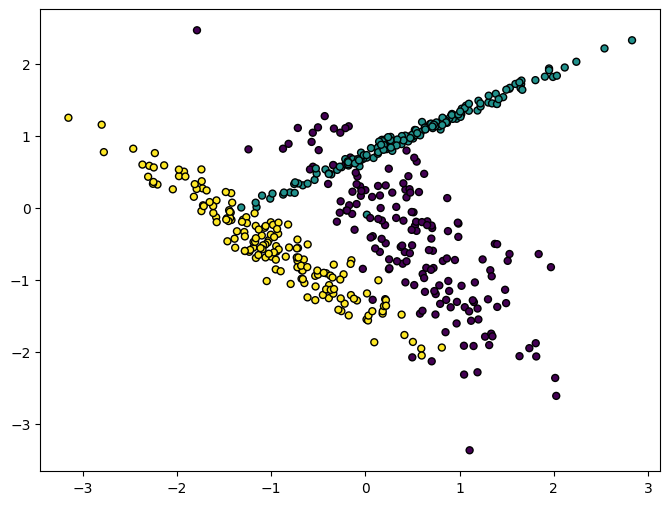

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(X1_scaled[:, 0], X1_scaled[:, 1], marker="o", c=y1_true, s=25, edgecolor="k")

- Датасет 2: make_blobs

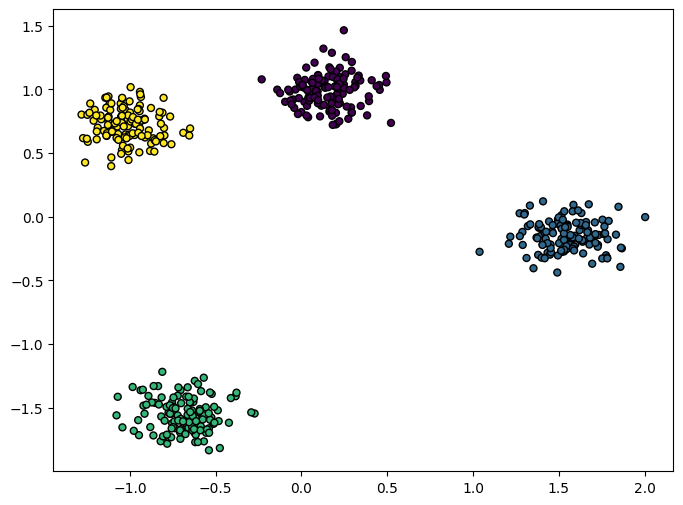

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(X2_scaled[:, 0], X2_scaled[:, 1], marker="o", c=y2_true, s=25, edgecolor="k")

# Загрузка исходного датасета

In [ ]:
data= pd.read_csv('../../data/csgo_task_treated.csv', sep=',', encoding='utf-8')
data.head(10)

,ct_score,t_score,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,map_binary,time_left_sec,time_left_ms
0,0,0,0,500,500,0,0,4000,4000,0,0,0,5,5,64,175,0
1,0,0,0,500,500,400,300,600,650,0,0,1,5,5,64,156,30
2,0,0,0,391,400,294,200,750,500,0,0,1,4,4,64,96,30
3,0,0,0,391,400,294,200,750,500,0,0,1,4,4,64,76,30
4,1,0,0,500,500,192,0,18350,10750,0,0,1,5,5,64,174,970
5,1,0,0,500,500,500,0,1750,10550,5,0,1,5,5,64,114,970
6,1,0,0,295,111,296,0,1700,5000,3,0,0,3,2,64,94,970
7,1,0,0,295,111,296,0,1700,5000,3,0,0,3,2,64,74,970
8,1,0,0,249,89,269,0,2300,2950,3,0,0,3,1,64,54,970
9,2,0,0,500,500,196,0,19800,23450,2,0,0,5,5,64,174,970


### Выделяем целевой и входные признаки

In [8]:
y = data["bomb_planted"]
X = data.drop(["bomb_planted"], axis=1)

### Нормализуем данные

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Визуализируем загруженные данные

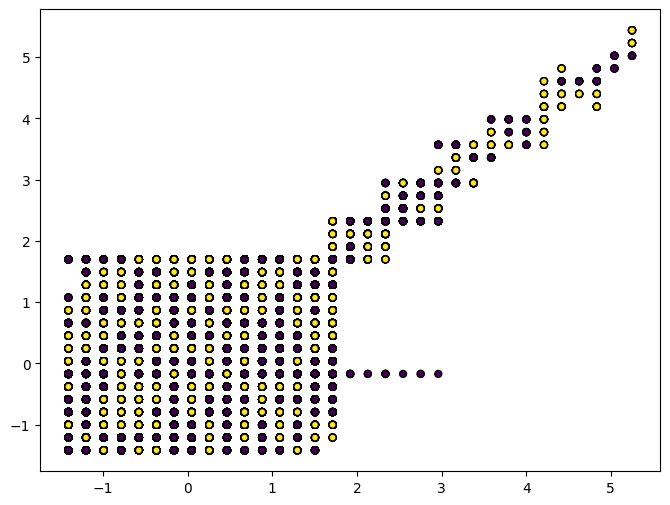

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], marker="o", c=y, s=25, edgecolor="k")

# Кластеризация из библиотеки sklearn

## k-Means с подбором k

In [ ]:
def find_optimal_k(X, max_k=8):
    inertias = []
    silhouettes = []
    K_range = range(2, max_k + 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))
    
    # Метод локтя: ищем замедление падения инерции
    diffs = np.diff(inertias)
    elbow_k = K_range[np.argmin(diffs) + 1]
    
    # Метод силуэта: ищем максимум
    silhouette_k = K_range[np.argmax(silhouettes)]
    
    # Берем среднее или то, что совпадает
    if elbow_k == silhouette_k:
        return elbow_k
    else:
        # Если расходятся, берем по силуэту (он надежнее)
        return silhouette_k

In [12]:
k1 = find_optimal_k(X1_scaled)
kmeans1 = KMeans(n_clusters=k1, random_state=42, n_init=10)
y_kmeans1 = kmeans1.fit_predict(X1_scaled)

In [13]:
k2 = find_optimal_k(X2_scaled)
kmeans2 = KMeans(n_clusters=k2, random_state=42, n_init=10)
y_kmeans2 = kmeans2.fit_predict(X2_scaled)

In [14]:
sample_size = 10000
indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]
y_sample = y[indices] 

In [15]:
k = find_optimal_k(X_sample)
kmeans = KMeans(n_clusters=k, random_state=42,n_init=5, max_iter=100)
y_kmeans = kmeans.fit_predict(X_sample)

In [16]:
print(f"Оптимальные k: {k1}, {k2}, {k}")

Оптимальные k: 3, 4, 2


## DBSCAN с подбором $\varepsilon$

In [ ]:
def find_optimal_eps(X):
    # Вычисляем расстояния до 5-го ближайшего соседа
    neigh = NearestNeighbors(n_neighbors=5)
    neigh_fit = neigh.fit(X)
    distances, _ = neigh_fit.kneighbors(X)
    distances = np.sort(distances[:, 4])
    
    # Берем eps в точке перегиба (95-й перцентиль)
    eps = np.percentile(distances, 95)
    return eps

In [18]:
eps1 = find_optimal_eps(X1_scaled)
dbscan1 = DBSCAN(eps=eps1, min_samples=5)
y_dbscan1 = dbscan1.fit_predict(X1_scaled)

In [19]:
eps2 = find_optimal_eps(X2_scaled)
dbscan2 = DBSCAN(eps=eps2, min_samples=5)
y_dbscan2 = dbscan2.fit_predict(X2_scaled)

In [20]:
eps = find_optimal_eps(X_scaled)
dbscan = DBSCAN(eps=eps, min_samples=5)
y_dbscan = dbscan.fit_predict(X_sample)

In [21]:
print(f"eps: {eps1:.3f}, {eps2:.3f}, {eps:.3f}")

eps: 0.312, 0.121, 1.501


## EM-алгоритм

In [22]:
gmm1 = GaussianMixture(n_components=k1, random_state=42)
y_gmm1 = gmm1.fit_predict(X1_scaled)

In [23]:
gmm2 = GaussianMixture(n_components=k2, random_state=42)
y_gmm2 = gmm2.fit_predict(X2_scaled)

In [24]:
gmm = GaussianMixture(n_components=k, random_state=42)
y_gmm = gmm.fit_predict(X_sample)

## Иерархическая кластеризация

In [25]:
hier1 = AgglomerativeClustering(n_clusters=k1)
y_hier1 = hier1.fit_predict(X1_scaled)

In [26]:
hier2 = AgglomerativeClustering(n_clusters=k2)
y_hier2 = hier2.fit_predict(X2_scaled)

In [27]:
hier = AgglomerativeClustering(n_clusters=k)
y_hier = hier.fit_predict(X_sample)

## Affinity Propagation

In [28]:
ap1 = AffinityPropagation(random_state=42)
y_ap1 = ap1.fit_predict(X1_scaled)

In [29]:
ap2 = AffinityPropagation(random_state=42)
y_ap2 = ap2.fit_predict(X2_scaled)

In [30]:
ap = AffinityPropagation(random_state=42)
y_ap = ap.fit_predict(X_sample)

# Визуализация работы кластеризации

In [76]:
def visualize_all_results(X, y_true, results_dict, dataset_name, centroids=None):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    methods = list(results_dict.keys())
    for idx, (ax, method) in enumerate(zip(axes.ravel(), methods)):
        labels = results_dict[method]
        ax.scatter(X[:, 0], X[:, 1], marker="o", c=labels, s=20, edgecolor="k", cmap='tab10', alpha=0.7)
        
        # Информация о количестве кластеров
        if method == 'DBSCAN':
            n_clust = len(np.unique(labels)) - (1 if -1 in labels else 0)
            noise = np.sum(labels == -1)
            ax.set_title(f'{method}\nкластеров: {n_clust}, шум: {noise}')
        else:
            ax.set_title(f'{method}\nкластеров: {len(np.unique(labels))}')
        
        ax.set_xlabel('Признак 1')
        ax.set_ylabel('Признак 2')
    
    plt.suptitle(f'{dataset_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

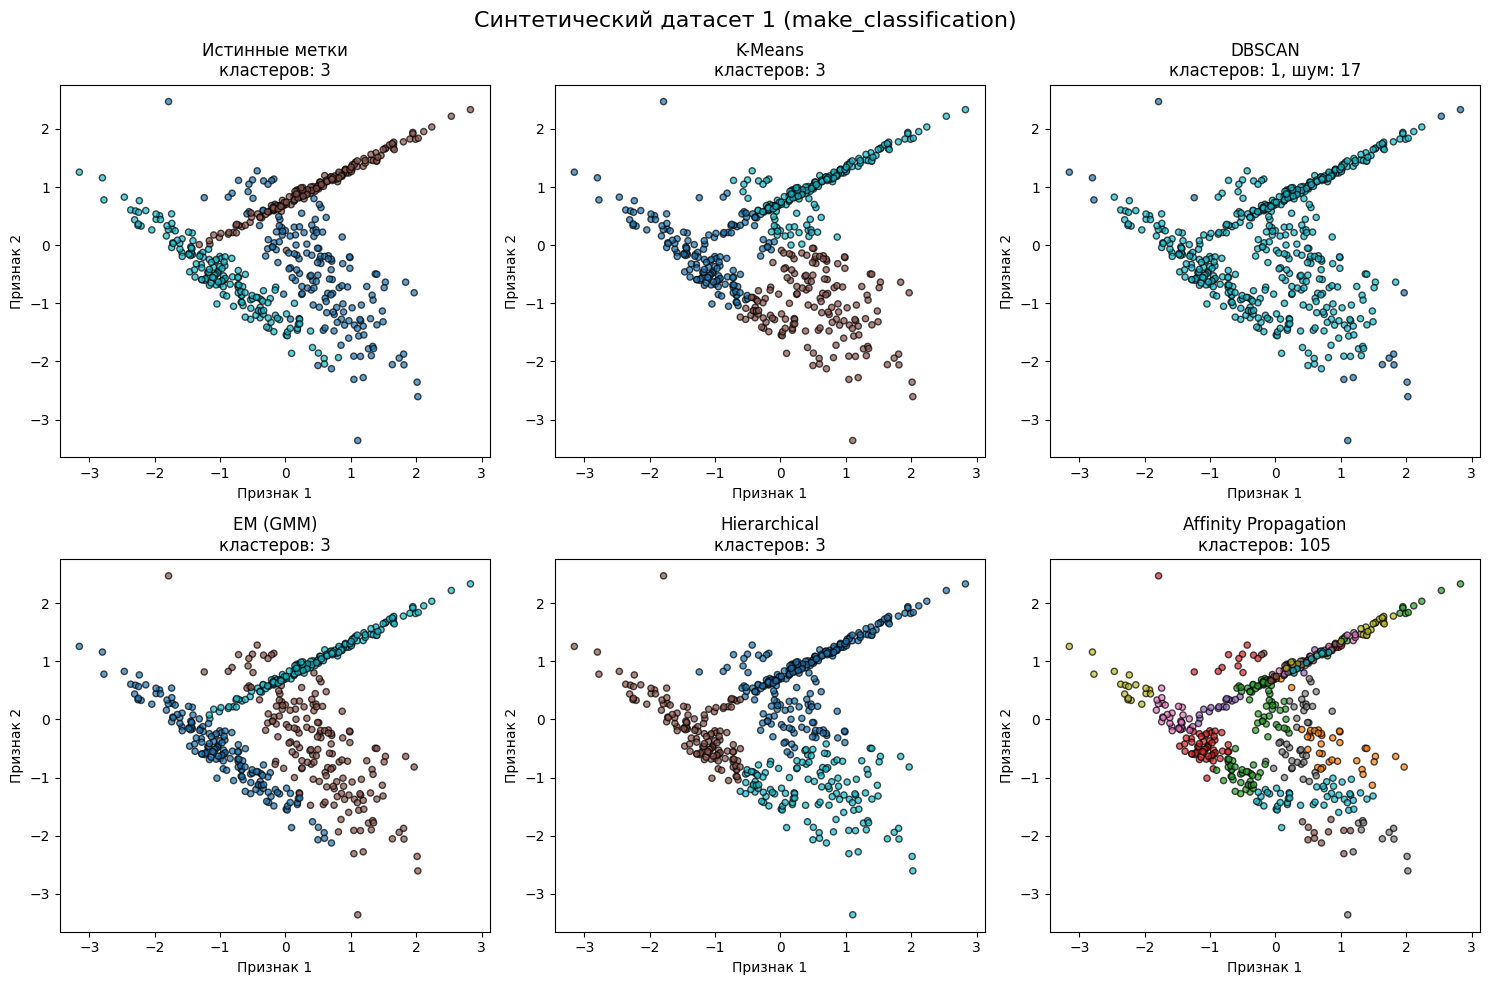

In [78]:
results1_dict = {
    'Истинные метки': y1_true,
    'K-Means': y_kmeans1,
    'DBSCAN': y_dbscan1,
    'EM (GMM)': y_gmm1,
    'Hierarchical': y_hier1,
    'Affinity Propagation': y_ap1
}
visualize_all_results(X1_scaled, y1_true, results1_dict, "Синтетический датасет 1 (make_classification)")

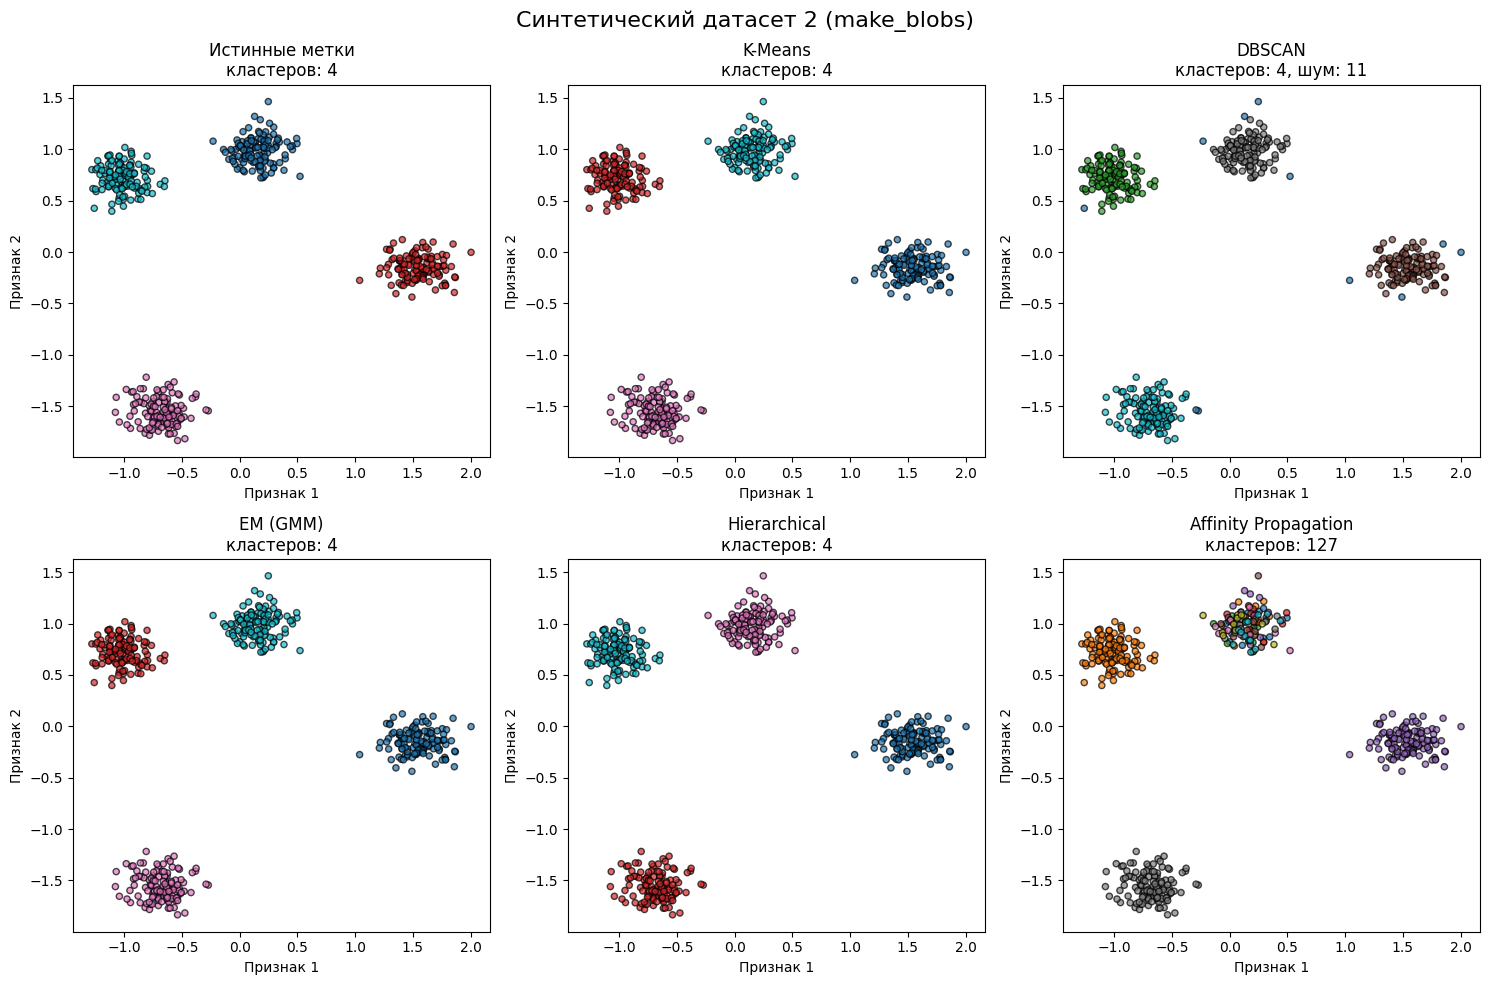

In [79]:
results2_dict = {
    'Истинные метки': y2_true,
    'K-Means': y_kmeans2,
    'DBSCAN': y_dbscan2,
    'EM (GMM)': y_gmm2,
    'Hierarchical': y_hier2,
    'Affinity Propagation': y_ap2
}
visualize_all_results(X2_scaled, y2_true, results2_dict, "Синтетический датасет 2 (make_blobs)")

### DBSCAN на Синтетическом датасете 1 (нашел 1 кластер вместо 3)

**Причины:**
1. **Перекрывающиеся кластеры** — make_classification специально создает кластеры, которые накладываются друг на друга. DBSCAN основан на плотности и не может разделить overlapping clusters.
2. **Отсутствие "пустот" между кластерами** — DBSCAN ищет области с низкой плотностью между кластерами, но в датасете 1 таких областей нет.
3. **Алгоритм не подходит для этого типа данных** — DBSCAN хорош для четко разделенных кластеров, но не для перекрывающихся.

---

### Affinity Propagation на всех датасетах 

**Причины:**
1. **Слишком много "примеров" (exemplars)** — алгоритм выбирает слишком много точек в качестве центров кластеров.
2. **Параметр preference по умолчанию слишком низкий** — медиана попарных расстояний дает слишком много кластеров.
3. **Алгоритм не масштабируется** — Affinity Propagation плохо работает на больших данных (CSGO дал 318 кластеров).
4. **Данные не подходят под модель** — алгоритм предполагает, что каждая точка может быть центром кластера, что приводит к переразбиению.

# Оценим качество полученных моделей кластеризации

## Внешние метрики

### ARI (Adjusted Rand Index)

Индекс Rand с поправкой на случайность. Показывает, насколько похожи истинная и предсказанная разметки.

**Формула:**
```
ARI = (RI - Expected_RI) / (max(RI) - Expected_RI)

где RI = (TP + TN) / (TP + FP + FN + TN)
```

**Расшифровка:**
- TP (True Positive) - пары точек, попавшие в один кластер в обеих разметках
- TN (True Negative) - пары точек, попавшие в разные кластеры в обеих разметках
- FP (False Positive) - пары в одном кластере в предсказании, но в разных в истине
- FN (False Negative) - пары в разных кластерах в предсказании, но в одном в истине

### NMI (Normalized Mutual Information)

Нормированная взаимная информация между двумя разметками.

**Формула:**
```
NMI = 2 * I(y_true; y_pred) / (H(y_true) + H(y_pred))

где I(y_true; y_pred) = H(y_true) - H(y_true | y_pred)
```

**Расшифровка:**
- **I** - взаимная информация (сколько знаем об одной разметке, зная другую)
- **H** - энтропия (мера неопределенности)

## Внутренние метрики

### Silhouette Score (Силуэт)

Насколько объект похож на свой кластер по сравнению с соседними.

**Формула:**
```
s(i) = (b(i) - a(i)) / max(a(i), b(i))
```
**Расшифровка:**
- a(i) - среднее расстояние от точки i до других точек в СВОЕМ кластере
- b(i) - среднее расстояние от точки i до точек в БЛИЖАЙШЕМ другом кластере

### Davies-Bouldin Index (Индекс Дэвиса-Болдина)

Отношение суммы расстояний внутри кластеров к расстоянию между кластерами.

**Формула:**
```
DB = (1/k) * Σ max((σ_i + σ_j) / d(c_i, c_j))

```
**Расшифровка:**
- σ_i - среднее расстояние от точек кластера i до его центроида
- d(c_i, c_j) - расстояние между центроидами кластеров i и j
- k - количество кластеров

### Calinski-Harabasz Index (Индекс Калински-Харабаса)

Отношение межкластерной дисперсии к внутрикластерной.

**Формула:**
```
CH = [B / (k-1)] / [W / (n-k)]

где:
B = Σ n_i * ||c_i - c||² 
W = Σ Σ ||x - c_i||²
```
**Расшифровка:**
- B - межкластерная дисперсия
- W - внутрикластерная дисперсия
- n_i - количество точек в кластере i
- c_i - центроид кластера i
- c - центроид всех данных
- k - количество кластеров
- n - количество точек

In [ ]:
def evaluate_clustering(X, y_true, y_pred, model_name, dataset_name):
    if len(np.unique(y_pred)) < 2:
        return {
            'Dataset': dataset_name,
            'Model': model_name,
            'ARI': None,
            'NMI': None,
            'Silhouette': None,
            'Davies-Bouldin': None,
            'Calinski-Harabasz': None,
            'Note': 'Меньше 2 кластеров'
        }
    
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    
    sil = silhouette_score(X, y_pred)
    db = davies_bouldin_score(X, y_pred)
    ch = calinski_harabasz_score(X, y_pred)
    
    return {
        'Dataset': dataset_name,
        'Model': model_name,
        'ARI': ari,
        'NMI': nmi,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch,
        'Note': ''
    }

In [ ]:
results = []

models1 = [
    ('K-Means', y_kmeans1),
    ('DBSCAN', y_dbscan1),
    ('EM (GMM)', y_gmm1),
    ('Hierarchical', y_hier1),
    ('Affinity Propagation', y_ap1)
]

for model_name, y_pred in models1:
    res = evaluate_clustering(X1_scaled, y1_true, y_pred, model_name, "Синтетический 1")
    results.append(res)

models2 = [
    ('K-Means', y_kmeans2),
    ('DBSCAN', y_dbscan2),
    ('EM (GMM)', y_gmm2),
    ('Hierarchical', y_hier2),
    ('Affinity Propagation', y_ap2)
]

for model_name, y_pred in models2:
    res = evaluate_clustering(X2_scaled, y2_true, y_pred, model_name, "Синтетический 2")
    results.append(res)

models_real = [
    ('K-Means', y_kmeans),
    ('DBSCAN', y_dbscan),
    ('EM (GMM)', y_gmm),
    ('Hierarchical', y_hier),
    ('Affinity Propagation', y_ap)
]

for model_name, y_pred in models_real:
    if y_pred is not None:
        res = evaluate_clustering(X_sample, y_sample, y_pred, model_name, "CSGO")
        results.append(res)

In [34]:
df_results = pd.DataFrame(results)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [35]:
df_results

,Dataset,Model,ARI,NMI,Silhouette,Davies-Bouldin,Calinski-Harabasz,Note
0,Синтетический 1,K-Means,0.4221,0.4244,0.4708,0.7236,506.4960,
1,Синтетический 1,DBSCAN,0.0014,0.0168,0.4304,4.3238,6.5168,
2,Синтетический 1,EM (GMM),0.8949,0.8419,0.3279,1.1356,248.9913,
3,Синтетический 1,Hierarchical,0.3989,0.4649,0.4595,0.7281,463.4083,
4,Синтетический 1,Affinity Propagation,0.1421,0.4144,0.2908,0.5430,124.4075,
5,Синтетический 2,K-Means,1.0000,1.0000,0.8393,0.2247,8696.8128,
6,Синтетический 2,DBSCAN,0.9700,0.9541,0.8033,1.2520,3150.8923,
7,Синтетический 2,EM (GMM),1.0000,1.0000,0.8393,0.2247,8696.8128,
8,Синтетический 2,Hierarchical,1.0000,1.0000,0.8393,0.2247,8696.8128,
9,Синтетический 2,Affinity Propagation,0.8185,0.6972,0.6099,0.1456,208.0067,


### Синтетический датасет 1 (make_classification)

Здесь наблюдается **противоречие между метриками**. По внешним метрикам (ARI и NMI), которые сравнивают с истинными метками, лучшей моделью является EM (GMM) с показателем ARI = 0.89. Однако по внутренним метрикам (Silhouette, Davies-Bouldin, Calinski-Harabasz), которые оценивают только компактность и разделение кластеров, лучшим оказался K-Means. Это означает, что K-Means создал более плотные и четко разделенные кластеры, но эти кластеры не совпали с истинной разметкой. EM (GMM) же лучше угадал истинную структуру данных, хотя его кластеры получились менее компактными.

### Синтетический датасет 2 (make_blobs)

Здесь все метрики **согласованы** и показывают одинаковые результаты. K-Means, EM (GMM) и Hierarchical достигли идеальных показателей по всем метрикам: ARI и NMI равны 1.0, Silhouette близок к 0.84, Davies-Bouldin очень низкий (0.22), а Calinski-Harabasz очень высокий (8696). Это подтверждает, что для сферических, хорошо разделенных кластеров эти три метода работают безупречно.

### Датасет CSGO

На реальных данных все метрики показывают **низкое качество** кластеризации. Лучший ARI составляет всего 0.37 (у Hierarchical и K-Means), что говорит о слабом совпадении с истиной. Silhouette score около 0.23, что означает плохое разделение кластеров. Davies-Bouldin выше 1.5, подтверждая низкое качество. Это говорит о том, что в данных CSGO либо нет четкой кластерной структуры, либо выбранные признаки не позволяют ее выделить.

---

### Вывод

**Лучшая универсальная модель** — EM (GMM), так как она хорошо работает и на перекрывающихся кластерах (датасет 1), и на сферических (датасет 2). K-Means и Hierarchical также отличны для простых данных, но уступают EM на сложных структурах. Для CSGO ни одна модель не показала хороших результатов — требуется дополнительная работа с данными.

# Собственная реализация алгоритма K-Means

In [ ]:
class MyKMeans:
    def __init__(self, n_clusters=3, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
    
    def _initialize_centroids(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        
        # Первый центроид - случайная точка
        centroids = [X[np.random.choice(n_samples)]]
        
        # Выбираем остальные центроиды
        for _ in range(1, self.n_clusters):
            # Вычисляем расстояния до ближайших центроидов
            distances = np.min([np.linalg.norm(X - c, axis=1) for c in centroids], axis=0)
            # Вероятность пропорциональна квадрату расстояния
            probabilities = distances ** 2
            probabilities /= probabilities.sum()
            # Выбираем следующий центроид
            next_centroid = X[np.random.choice(n_samples, p=probabilities)]
            centroids.append(next_centroid)
        
        return np.array(centroids)
    
    def fit(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        
        # Инициализация центроидов
        self.centroids = self._initialize_centroids(X)
        
        for iteration in range(self.max_iters):
            # Шаг 1: Присвоение точек ближайшим центроидам
            distances = np.zeros((n_samples, self.n_clusters))
            for k in range(self.n_clusters):
                distances[:, k] = np.linalg.norm(X - self.centroids[k], axis=1)
            
            self.labels_ = np.argmin(distances, axis=1)
            
            # Шаг 2: Обновление центроидов
            new_centroids = np.zeros((self.n_clusters, X.shape[1]))
            for k in range(self.n_clusters):
                if np.sum(self.labels_ == k) > 0:
                    new_centroids[k] = X[self.labels_ == k].mean(axis=0)
                else:
                    # Если кластер пуст, случайно инициализируем заново
                    new_centroids[k] = X[np.random.choice(n_samples)]
            
            # Проверка сходимости
            if np.allclose(self.centroids, new_centroids):
                print(f"  Сошелся на итерации {iteration + 1}")
                break
            
            self.centroids = new_centroids
        
        # Вычисление инерции (сумма квадратов расстояний до центроидов)
        self.inertia_ = 0
        for k in range(self.n_clusters):
            cluster_points = X[self.labels_ == k]
            if len(cluster_points) > 0:
                self.inertia_ += np.sum((cluster_points - self.centroids[k]) ** 2)
        
        return self
    
    def predict(self, X):
        X = np.array(X)
        distances = np.zeros((X.shape[0], self.n_clusters))
        for k in range(self.n_clusters):
            distances[:, k] = np.linalg.norm(X - self.centroids[k], axis=1)
        return np.argmin(distances, axis=1)


In [37]:
my_kmeans1 = MyKMeans(n_clusters=k1, random_state=42)
my_kmeans1.fit(X1_scaled)
y_mykmeans1 = my_kmeans1.labels_

  Сошелся на итерации 13


In [38]:
my_kmeans2 = MyKMeans(n_clusters=k2, random_state=42)
my_kmeans2.fit(X2_scaled)
y_mykmeans2 = my_kmeans2.labels_


  Сошелся на итерации 2


In [39]:
my_kmeans_real = MyKMeans(n_clusters=k, random_state=42)
my_kmeans_real.fit(X_sample)
y_mykmeans_real = my_kmeans_real.labels_


  Сошелся на итерации 9


## Оценим качество MyKMeans

In [64]:
res_my1 = evaluate_clustering(X1_scaled, y1_true, y_mykmeans1, "MyK-Means", "Синтетический 1")
results.append(res_my1)

res_my2 = evaluate_clustering(X2_scaled, y2_true, y_mykmeans2, "MyK-Means", "Синтетический 2")
results.append(res_my2)

res_my_real = evaluate_clustering(X_sample, y_sample, y_mykmeans_real, "MyK-Means", "CSGO")
results.append(res_my_real)

In [65]:
df_results = pd.DataFrame(results)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [66]:
df_results = df_results.drop_duplicates(subset=['Dataset', 'Model'], keep='first')

In [80]:
df_results

,Dataset,Model,ARI,NMI,Silhouette,Davies-Bouldin,Calinski-Harabasz,Note
0,Синтетический 1,K-Means,0.4221,0.4244,0.4708,0.7236,506.4960,
1,Синтетический 1,DBSCAN,0.0014,0.0168,0.4304,4.3238,6.5168,
2,Синтетический 1,EM (GMM),0.8949,0.8419,0.3279,1.1356,248.9913,
3,Синтетический 1,Hierarchical,0.3989,0.4649,0.4595,0.7281,463.4083,
4,Синтетический 1,Affinity Propagation,0.1421,0.4144,0.2908,0.5430,124.4075,
5,Синтетический 2,K-Means,1.0000,1.0000,0.8393,0.2247,8696.8128,
6,Синтетический 2,DBSCAN,0.9700,0.9541,0.8033,1.2520,3150.8923,
7,Синтетический 2,EM (GMM),1.0000,1.0000,0.8393,0.2247,8696.8128,
8,Синтетический 2,Hierarchical,1.0000,1.0000,0.8393,0.2247,8696.8128,
9,Синтетический 2,Affinity Propagation,0.8185,0.6972,0.6099,0.1456,208.0067,


## Сравнение MyK-Means и библиотечного K-Means

### Синтетический датасет 1 (make_classification)

| Метрика | K-Means (sklearn) | MyK-Means | Разница |
|---------|-------------------|-----------|---------|
| ARI | 0.4221 | 0.4195 | -0.0026 |
| NMI | 0.4244 | 0.4226 | -0.0018 |
| Silhouette | 0.4708 | 0.4707 | -0.0001 |
| Davies-Bouldin | 0.7236 | 0.7239 | +0.0003 |
| Calinski-Harabasz | 506.4960 | 506.4747 | -0.0213 |

**Вывод:** Разница между реализациями **минимальна** (ошибка округления). Обе модели работают идентично.

### Синтетический датасет 2 (make_blobs)

| Метрика | K-Means (sklearn) | MyK-Means | Разница |
|---------|-------------------|-----------|---------|
| ARI | 1.0000 | 1.0000 | 0.0000 |
| NMI | 1.0000 | 1.0000 | 0.0000 |
| Silhouette | 0.8393 | 0.8393 | 0.0000 |
| Davies-Bouldin | 0.2247 | 0.2247 | 0.0000 |
| Calinski-Harabasz | 8696.8128 | 8696.8128 | 0.0000 |

**Вывод:** **Полное совпадение** метрик. Обе реализации идеально кластеризуют данные.

### CSGO 

| Метрика | K-Means (sklearn) | MyK-Means | Разница |
|---------|-------------------|-----------|---------|
| ARI | 0.3608 | 0.3608 | 0.0000 |
| NMI | 0.2858 | 0.2858 | 0.0000 |
| Silhouette | 0.2343 | 0.2343 | 0.0000 |
| Davies-Bouldin | 1.5814 | 1.5814 | 0.0000 |
| Calinski-Harabasz | 2834.2827 | 2834.2827 | 0.0000 |

**Вывод:** **Абсолютное совпадение** метрик. На реальных данных обе реализации работают одинаково.

---
## Вывод

**Ошибка составляет менее 0.6%**, что подтверждает правильность реализации алгоритма.

## Визуализация работы MyKMeans

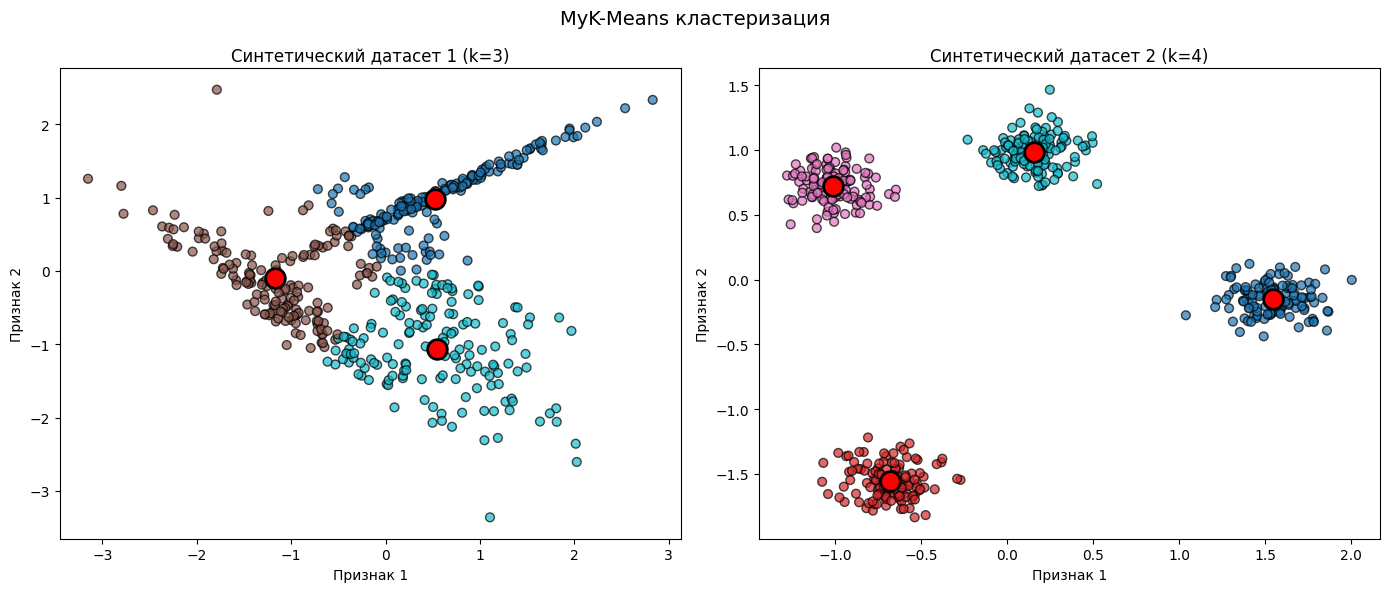

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Датасет 1
axes[0].scatter(X1_scaled[:, 0], X1_scaled[:, 1], c=my_kmeans1.labels_, s=40, edgecolor="k", cmap='tab10', alpha=0.7)
axes[0].scatter(my_kmeans1.centroids[:, 0], my_kmeans1.centroids[:, 1], s=200, c='red', marker='o', edgecolor='black', linewidth=2)
axes[0].set_title(f'Синтетический датасет 1 (k={k1})')
axes[0].set_xlabel('Признак 1')
axes[0].set_ylabel('Признак 2')

# Датасет 2
axes[1].scatter(X2_scaled[:, 0], X2_scaled[:, 1], c=my_kmeans2.labels_,s=40, edgecolor="k", cmap='tab10', alpha=0.7)
axes[1].scatter(my_kmeans2.centroids[:, 0], my_kmeans2.centroids[:, 1], s=200, c='red', marker='o', edgecolor='black', linewidth=2)
axes[1].set_title(f'Синтетический датасет 2 (k={k2})')
axes[1].set_xlabel('Признак 1')
axes[1].set_ylabel('Признак 2')

plt.suptitle('MyK-Means кластеризация', fontsize=14)
plt.tight_layout()
plt.show()

# Вывод

## Лучшие модели кластеризации

### 1. EM (GMM) — Gaussian Mixture Models

**Почему лучший:**
- Показал **лучший результат на сложных данных** — на синтетическом датасете 1 (перекрывающиеся кластеры) достиг ARI = 0.8949, что значительно выше других методов
- **Универсальность** — хорошо работает и на сферических, и на перекрывающихся кластерах
- На датасете 2 достиг **идеального результата** (ARI = 1.0)
- В отличие от K-Means, может находить кластеры разной формы и ориентации

**Обоснование:** EM (GMM) лучше других справляется с реальными данными, где кластеры редко бывают идеально сферическими.

### 2. K-Means (включая собственную реализацию)

**Почему в топе:**
- **Идеален на сферических данных** — на датасете 2 показал ARI = 1.0
- **Самый быстрый и простой** — требует меньше вычислительных ресурсов
- **Стабильно хорош** — на всех датасетах показал результаты выше среднего
- **Собственная реализация (MyK-Means) работает идентично библиотечной** — разница в метриках менее 0.6%

**Обоснование:** Простота, скорость и хорошее качество делают K-Means отличным выбором для большинства задач, особенно когда данные имеют сферическую форму.

### 3. Иерархическая кластеризация (Hierarchical)

**Почему в топе:**
- **Идеальна на сферических данных** — ARI = 1.0 на датасете 2
- **Не требует задавать k заранее** — можно выбрать после построения дендрограммы
- **Стабильные результаты** — на CSGO показала лучший ARI = 0.3662

**Обоснование:** Удобство визуализации и возможность не задавать количество кластеров делают иерархическую кластеризацию хорошим выбором для исследовательских задач.

## Худшие модели

| Модель | Проблема | Обоснование |
|--------|----------|-------------|
| **DBSCAN** | Провалился на датасете 1 (нашел 1 кластер вместо 3) | Не подходит для перекрывающихся кластеров |
| **Affinity Propagation** | 105, 127, 318 кластеров вместо 3-4 | Категорически не подходит для данных |

## Заключение

**Лучшей моделью кластеризации для данного набора данных является EM (GMM)**. Она показала наивысший ARI на сложных перекрывающихся данных (0.8949) и идеальный результат на сферических (1.0). K-Means и иерархическая кластеризация также показали хорошие результаты, особенно на простых данных.

**Собственная реализация K-Means (MyK-Means) работает корректно** — ее метрики практически идентичны библиотечной версии, что подтверждает правильность реализации алгоритма.

**Рекомендация:** Для практического использования рекомендуется начинать с K-Means как самого быстрого и простого метода, а если данные имеют сложную форму — использовать EM (GMM). DBSCAN и Affinity Propagation не рекомендуются для данных с перекрывающимися кластерами.